# Rectangular Dielectric Waveguide Modes

This notebook solves a dielectric core inside cladding, classifies guided modes, and plots transverse and longitudinal fields.

In [ ]:
from palacetoolkit.mode_solver import WaveguideModeSolver

import os
import tempfile
from pathlib import Path

import gmsh
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def _write_and_finalize(filename=None):
    if filename is None:
        fd, filename = tempfile.mkstemp(suffix=".msh", prefix="wg_diel_")
        os.close(fd)
    filename = str(Path(filename).resolve())
    gmsh.option.setNumber("Mesh.MshFileVersion", 2.2)
    gmsh.write(filename)
    gmsh.finalize()
    return filename


def _set_lc_for_dielectric(a_core, b_core, lc_core, lc_clad):
    pts = gmsh.model.getEntities(0)
    for _, ptag in pts:
        coord = gmsh.model.getValue(0, ptag, [])
        in_core = (abs(coord[0]) <= a_core / 2 + 1e-10 and abs(coord[1]) <= b_core / 2 + 1e-10)
        gmsh.model.mesh.setSize([(0, ptag)], lc_core if in_core else lc_clad)


def make_dielectric_waveguide_mesh(a_core, b_core, a_clad, b_clad, nx_core=16, ny_core=8, nx_clad=8, ny_clad=8, filename=None):
    gmsh.initialize()
    gmsh.option.setNumber("General.Verbosity", 0)
    gmsh.model.add("dielectric_waveguide")

    clad = gmsh.model.occ.addRectangle(-a_clad / 2, -b_clad / 2, 0, a_clad, b_clad)
    core = gmsh.model.occ.addRectangle(-a_core / 2, -b_core / 2, 0, a_core, b_core)
    _, outmap = gmsh.model.occ.fragment([(2, clad)], [(2, core)])
    gmsh.model.occ.synchronize()

    core_surfs = [tag for _, tag in outmap[1]]
    clad_surfs = [tag for _, tag in outmap[0] if tag not in core_surfs]

    gmsh.model.addPhysicalGroup(2, core_surfs, tag=1, name="core")
    gmsh.model.addPhysicalGroup(2, clad_surfs, tag=2, name="cladding")

    all_surfs = [(2, t) for t in core_surfs + clad_surfs]
    outer_bnd = gmsh.model.getBoundary(all_surfs, oriented=False, combined=True)
    pec_tags = [abs(tag) for _, tag in outer_bnd]
    gmsh.model.addPhysicalGroup(1, pec_tags, tag=1, name="PEC")

    lc_core = min(a_core / nx_core, b_core / ny_core)
    lc_clad = max(lc_core * max(nx_core / nx_clad, ny_core / ny_clad), 1.5 * lc_core)
    _set_lc_for_dielectric(a_core, b_core, lc_core, lc_clad)

    gmsh.model.mesh.generate(2)
    return _write_and_finalize(filename)

In [4]:
a_core, b_core = 1.0, 0.5
a_clad, b_clad = 4.0, 3.0
eps_core, eps_clad = 4.0, 1.0
mu = 1.0

k0_cutoff_approx = np.pi / a_core / np.sqrt(eps_core - eps_clad)
omega = 3.0 * k0_cutoff_approx

kn_min = omega * np.sqrt(mu * eps_clad)
kn_max = omega * np.sqrt(mu * eps_core)
print(f"Guided-mode window: {kn_min:.4f} < kn < {kn_max:.4f}")

Guided-mode window: 5.4414 < kn < 10.8828


In [5]:
mesh_file = make_dielectric_waveguide_mesh(a_core, b_core, a_clad, b_clad, nx_core=16, ny_core=8, nx_clad=8, ny_clad=8)
mu_inv_dict = {1: 1.0 / mu, 2: 1.0 / mu}
eps_dict = {1: eps_core, 2: eps_clad}

solver = WaveguideModeSolver(mesh_file, order=2, mu_inv=mu_inv_dict, eps=eps_dict, pec_bdr="all")
results = solver.solve(omega, num_modes=10, mode_idx=1)

print("Computed modes:")
for i, kn in enumerate(results["kn"], start=1):
    if kn_min < kn.real < kn_max:
        mode_type = "guided"
    elif abs(kn.imag) > 0.1 * abs(kn.real):
        mode_type = "evanescent"
    else:
        mode_type = "radiation/substrate"
    print(f"  Mode {i:2d}: kn={kn.real:+10.6f}{kn.imag:+10.6f}j  [{mode_type}]")

  FE spaces: ND dofs = 15722, H1 dofs = 6357, total = 22079
  Essential DOFs: ND = 224, H1 = 224, total = 448
  Solving eigenvalue problem (omega = 5.4414, sigma = -130.279, size = 22079)...
  Found 10 modes:
    Mode 1: kn = +9.51611978e+00 -0.00000000e+00j <-- selected
    Mode 2: kn = +8.98886548e+00 -0.00000000e+00j
    Mode 3: kn = +8.06679983e+00 -0.00000000e+00j
    Mode 4: kn = +7.86873770e+00 -0.00000000e+00j
    Mode 5: kn = +6.41320112e+00 -0.00000000e+00j
    Mode 6: kn = +6.00582037e+00 -0.00000000e+00j
    Mode 7: kn = +5.85640924e+00 -0.00000000e+00j
    Mode 8: kn = +5.54115884e+00 -0.00000000e+00j
    Mode 9: kn = +5.31151432e+00 -0.00000000e+00j
    Mode 10: kn = +5.27932424e+00 -0.00000000e+00j
Computed modes:
  Mode  1: kn= +9.516120 -0.000000j  [guided]
  Mode  2: kn= +8.988865 -0.000000j  [guided]
  Mode  3: kn= +8.066800 -0.000000j  [guided]
  Mode  4: kn= +7.868738 -0.000000j  [guided]
  Mode  5: kn= +6.413201 -0.000000j  [guided]
  Mode  6: kn= +6.005820 -0.000

  Solving eigenvalue problem (omega = 5.4414, sigma = -130.279, size = 22079)...
  Found 10 modes:
    Mode 1: kn = +9.51611978e+00 -0.00000000e+00j <-- selected
    Mode 2: kn = +8.98886548e+00 -0.00000000e+00j
    Mode 3: kn = +8.06679983e+00 -0.00000000e+00j
    Mode 4: kn = +7.86873770e+00 -0.00000000e+00j
    Mode 5: kn = +6.41320112e+00 -0.00000000e+00j
    Mode 6: kn = +6.00582037e+00 -0.00000000e+00j
    Mode 7: kn = +5.85640924e+00 -0.00000000e+00j
    Mode 8: kn = +5.54115884e+00 -0.00000000e+00j
    Mode 9: kn = +5.31151432e+00 -0.00000000e+00j
    Mode 10: kn = +5.27932424e+00 -0.00000000e+00j
  Solving eigenvalue problem (omega = 5.4414, sigma = -130.279, size = 22079)...
  Found 10 modes:
    Mode 1: kn = +9.51611978e+00 -0.00000000e+00j
    Mode 2: kn = +8.98886548e+00 -0.00000000e+00j <-- selected
    Mode 3: kn = +8.06679983e+00 -0.00000000e+00j
    Mode 4: kn = +7.86873770e+00 -0.00000000e+00j
    Mode 5: kn = +6.41320112e+00 -0.00000000e+00j
    Mode 6: kn = +6.00582

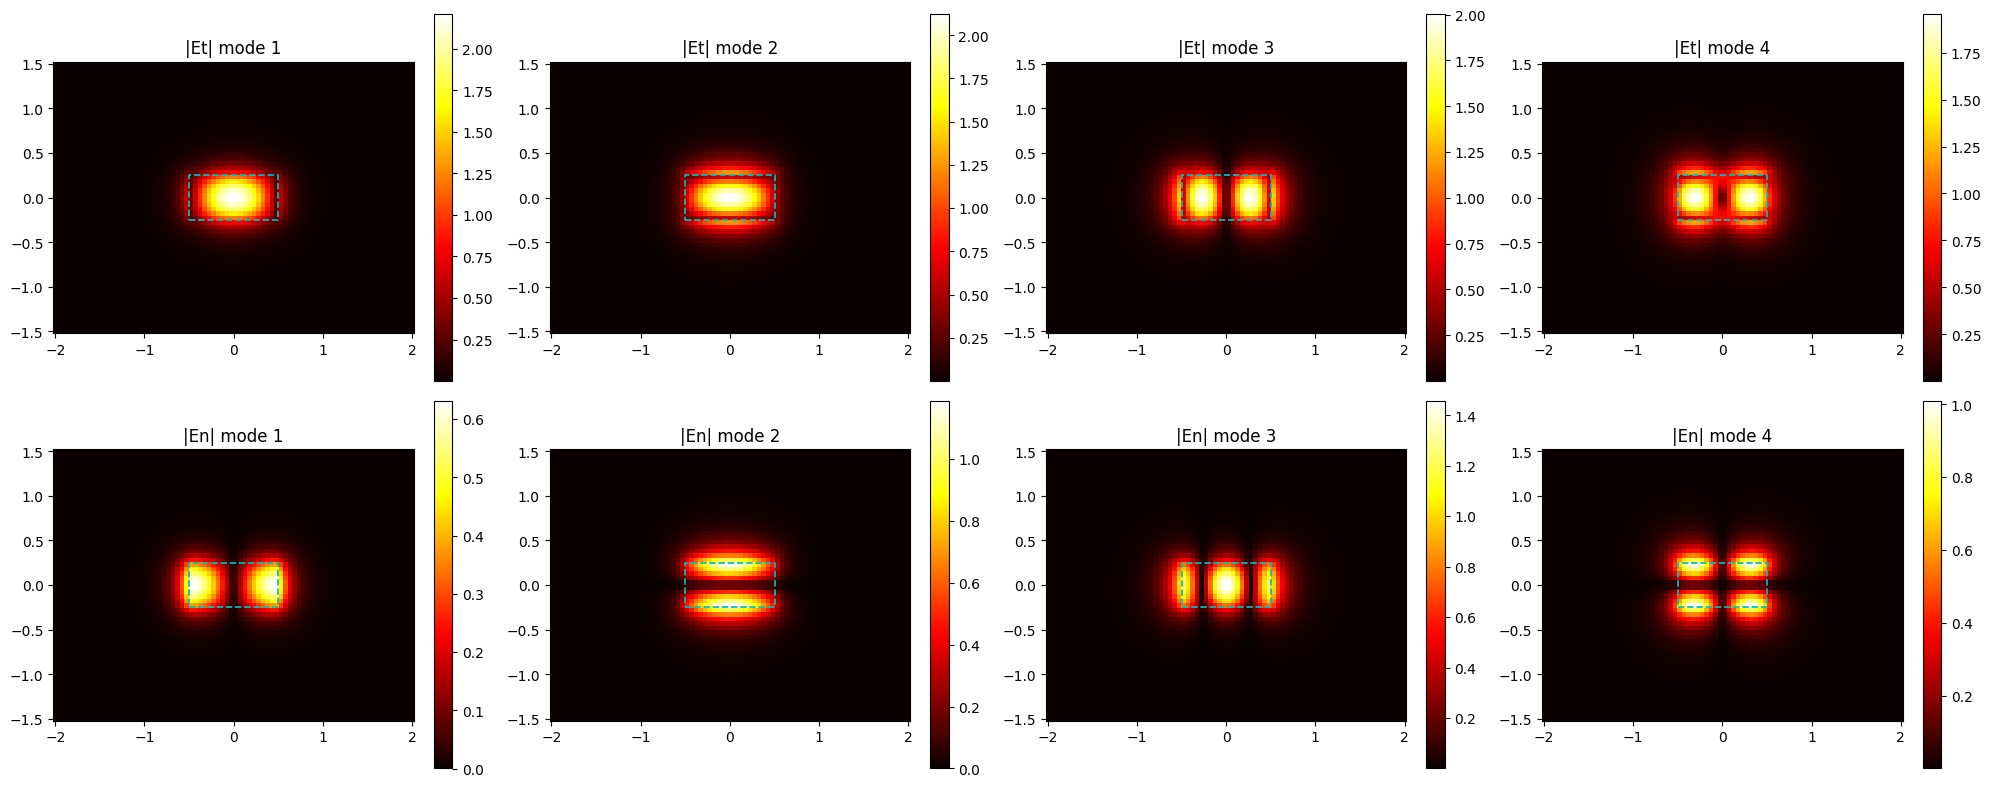

In [6]:
guided = [i for i, kn in enumerate(results["kn"]) if kn_min < kn.real < kn_max]
if not guided:
    guided = list(range(min(4, len(results["kn"]))))

n_plot = min(4, len(guided))
fig, axes = plt.subplots(2, max(1, n_plot), figsize=(5 * max(1, n_plot), 8))
if n_plot == 1:
    axes = axes.reshape(2, 1)

for j, mode_i in enumerate(guided[:n_plot]):
    r = solver.solve(omega, num_modes=10, mode_idx=mode_i + 1)
    X, Y, Ex, Ey, Ez = solver.get_field_on_grid(r["Et_vec"], r["En_vec"], nx=80, ny=60)

    Et_mag = np.sqrt(np.abs(Ex) ** 2 + np.abs(Ey) ** 2)
    En_mag = np.abs(Ez)

    ax = axes[0, j]
    im = ax.pcolormesh(X, Y, Et_mag, cmap="hot", shading="auto")
    ax.plot([-a_core/2, a_core/2, a_core/2, -a_core/2, -a_core/2], [-b_core/2, -b_core/2, b_core/2, b_core/2, -b_core/2], "c--", linewidth=1.25)
    ax.set_title(f"|Et| mode {mode_i+1}")
    ax.set_aspect("equal")
    fig.colorbar(im, ax=ax, fraction=0.046)

    ax = axes[1, j]
    im = ax.pcolormesh(X, Y, En_mag, cmap="hot", shading="auto")
    ax.plot([-a_core/2, a_core/2, a_core/2, -a_core/2, -a_core/2], [-b_core/2, -b_core/2, b_core/2, b_core/2, -b_core/2], "c--", linewidth=1.25)
    ax.set_title(f"|En| mode {mode_i+1}")
    ax.set_aspect("equal")
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()